# Notebook 04 — Funnel, Churn & Cohort Analysis

**Project:** Mirae Asset Digital Platform — User Analytics  
**Phases covered:** Phase 5 · Phase 6 · Phase 7  
**Objective:** Map the full user journey — from first touchpoint to conversion, understand why users leave, and track how different cohorts retain and generate revenue over time.

| Phase | Focus | Key output |
|-------|-------|------------|
| 5 | Funnel Analysis | Conversion rates, drop-off stages, channel & device breakdown |
| 6 | Advanced Churn Analysis | Behavioural, temporal & segment-level churn drivers |
| 7 | Cohort Analysis | Retention heatmap, LTV curves, repeat purchase cohorts |


## Table of Contents

**Phase 5 — Funnel Analysis**  
5.1 [Overall Conversion Funnel](#51)  
5.2 [Stage-by-Stage Drop-off](#52)  
5.3 [Funnel by Acquisition Channel](#53)  
5.4 [Funnel by Device](#54)  
5.5 [Time-to-Conversion](#55)  
5.6 [Repeat Purchase Behaviour](#56)  

**Phase 6 — Advanced Churn Analysis**  
6.1 [Behavioural Comparison: Churned vs Active](#61)  
6.2 [Churn by Demographics](#62)  
6.3 [Temporal Churn Patterns](#63)  
6.4 [Pre-Churn Engagement Signals](#64)  
6.5 [RFM Risk Scoring](#65)  

**Phase 7 — Cohort Analysis**  
7.1 [Retention Matrix & Heatmap](#71)  
7.2 [Retention Curves by Cohort](#72)  
7.3 [Cumulative Revenue per User](#73)  
7.4 [Cohort LTV Curves](#74)  
7.5 [Repeat Purchase by First-Purchase Cohort](#75)  
7.6 [Cohort Summary Dashboard](#76)  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import os
from pathlib import Path
def find_project_root(start=None):
    current = Path(start or os.getcwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return str(candidate)
    return str(current.parent if current.name == 'notebooks' else current)

BASE = find_project_root()

user_data    = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'user_data.csv'),
                            parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
raw_users    = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'users.csv'),
                            parse_dates=['signup_date'])
if 'is_registered' not in raw_users.columns:
    raw_users['is_registered'] = 1
events       = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'events.csv'),
                            parse_dates=['event_date'])
events = events.merge(raw_users[['user_id','signup_date']], on='user_id', how='left')
events = events[events['event_date'] >= events['signup_date']].drop(columns='signup_date')
sessions     = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'sessions.csv'),
                            parse_dates=['session_date'])
sessions = sessions.merge(user_data[['user_id','signup_date']], on='user_id', how='left')
sessions = sessions[sessions['session_date'] >= sessions['signup_date']].drop(columns='signup_date')
transactions = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'transactions.csv'),
                            parse_dates=['transaction_date'])
transactions = transactions.merge(user_data[['user_id','signup_date']], on='user_id', how='left')
transactions = transactions[transactions['transaction_date'] >= transactions['signup_date']].drop(columns='signup_date')
# Enforce dtypes
user_data['churn']           = user_data['churn'].astype(int)
user_data['has_purchased']   = user_data['has_purchased'].astype(int)
user_data['total_sessions']  = user_data['total_sessions'].astype(int)
user_data['total_purchases'] = user_data['total_purchases'].astype(int)
user_data['churn_label']     = user_data['churn'].map({0: 'Active', 1: 'Churned'})
user_data['cohort_month']    = user_data['signup_date'].dt.to_period('M')

churn_palette = {'Active': 'steelblue', 'Churned': 'salmon'}
latest_date   = sessions['session_date'].max()

print(f'Users        : {len(user_data):,}')
print(f'Events       : {len(events):,}')
print(f'Sessions     : {len(sessions):,}')
print(f'Transactions : {len(transactions):,}')
print(f'Baseline churn rate : {user_data["churn"].mean():.1%}')
print(f'Event types  : {sorted(events["event_type"].unique())}')


Users        : 10,000
Events       : 90,000
Sessions     : 50,000
Transactions : 15,000
Baseline churn rate : 17.4%
Event types  : ['add_to_cart', 'purchase', 'signup', 'visit']


---
## Phase 5 — Funnel Analysis

> **Goal:** Identify where users drop off on the path from first visit to repeat purchase. Every drop-off is a quantified revenue recovery opportunity.


---
## Step 2: Define the Funnel Stages

The funnel represents a causal user journey from first platform visit to purchase. Each stage is counted cumulatively: a user is counted at a later stage only if they completed all previous stages in chronological order.

| Stage | Event | Description |
|-------|-------|-------------|
| 1 | `visit` | User lands on the platform |
| 2 | `signup` | User creates an account |
| 3 | `add_to_cart` | User shows purchase intent |
| 4 | `purchase` | User completes a transaction |


In [2]:
# Define ordered funnel stages
FUNNEL_STAGES = ['visit', 'signup', 'add_to_cart', 'purchase']
STAGE_LABELS  = ['Visit', 'Signup', 'Add to Cart', 'Purchase']

def cumulative_funnel_masks(first_events):
    first_events = first_events.reindex(columns=FUNNEL_STAGES)
    masks = {}
    prior_mask = pd.Series(True, index=first_events.index)
    prior_date = None
    for stage in FUNNEL_STAGES:
        stage_date = first_events[stage]
        mask = prior_mask & stage_date.notna()
        if prior_date is not None:
            mask &= stage_date >= prior_date
        masks[stage] = mask
        prior_mask = mask
        prior_date = stage_date
    return masks

funnel_first = events.pivot_table(
    index='user_id', columns='event_type', values='event_date', aggfunc='min'
)
funnel_masks = cumulative_funnel_masks(funnel_first)
funnel_users = {stage: int(mask.sum()) for stage, mask in funnel_masks.items()}

funnel_df = pd.DataFrame({
    'stage'       : STAGE_LABELS,
    'event_type'  : FUNNEL_STAGES,
    'users'       : [funnel_users[s] for s in FUNNEL_STAGES]
})

# Conversion rates
funnel_df['pct_of_top']   = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
funnel_df['step_conv']    = funnel_df['users'] / funnel_df['users'].shift(1) * 100
funnel_df['step_dropoff'] = 100 - funnel_df['step_conv']

assert funnel_df['users'].is_monotonic_decreasing, 'Funnel must be cumulative and monotonic.'
print(funnel_df.to_string(index=False))


      stage  event_type  users  pct_of_top  step_conv  step_dropoff
      Visit       visit  12500       100.0        NaN           NaN
     Signup      signup  10000        80.0  80.000000     20.000000
Add to Cart add_to_cart   7000        56.0  70.000000     30.000000
   Purchase    purchase   4800        38.4  68.571429     31.428571


**Note on methodology:** We count unique users per stage, not total events. A user who visited 10 times counts once at the Visit stage. This gives us a true picture of how many distinct people progressed through each step, rather than inflated event counts driven by repeat actions.

---
## Step 3: Overall Funnel Visualisation

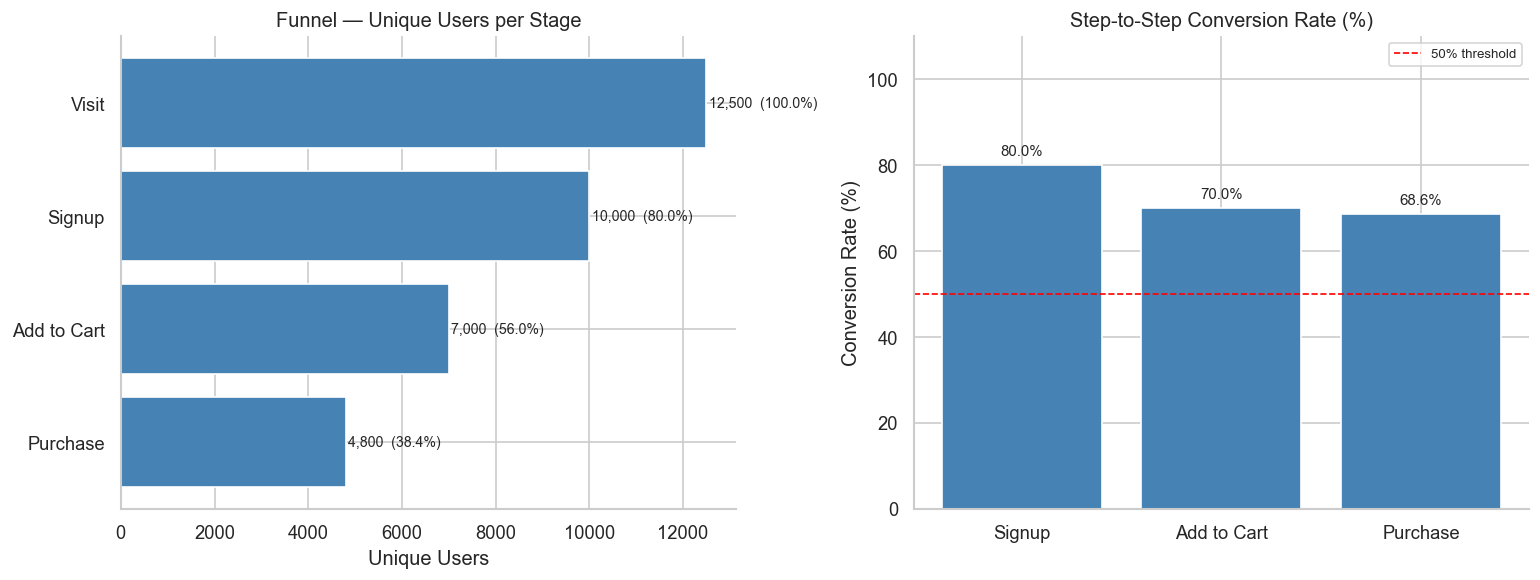

End-to-end conversion (Visit → Purchase): 38.4%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Funnel bar chart ---
bars = axes[0].barh(
    funnel_df['stage'][::-1],
    funnel_df['users'][::-1],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Funnel — Unique Users per Stage')
axes[0].set_xlabel('Unique Users')
for bar, (_, row) in zip(bars, funnel_df[::-1].iterrows()):
    axes[0].text(
        bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
        f'{int(row["users"]):,}  ({row["pct_of_top"]:.1f}%)',
        va='center', fontsize=8.5
    )

# --- Right: Step-by-step conversion rate ---
step_data = funnel_df.iloc[1:]  # skip top-of-funnel (no prior step)
axes[1].bar(
    step_data['stage'], step_data['step_conv'],
    color='steelblue', edgecolor='white'
)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1,
                label='50% threshold')
axes[1].set_title('Step-to-Step Conversion Rate (%)')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=8)
for bar, val in zip(axes[1].patches, step_data['step_conv']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

# Overall end-to-end conversion
e2e = funnel_df['users'].iloc[-1] / funnel_df['users'].iloc[0] * 100
print(f'End-to-end conversion (Visit → Purchase): {e2e:.1f}%')

**Observation:** The funnel chart shows the absolute volume at each cumulative stage, while the step conversion chart shows the rate of progression between stages. The most important number is the end-to-end conversion rate: what percentage of visitors ultimately purchase after completing the required prior steps. The step with the lowest conversion rate is the primary bottleneck and the highest-priority target for product and marketing intervention.


---
## Step 4: Drop-off Analysis
For each transition, we calculate how many users were lost and what that loss represents as a percentage of the top-of-funnel.

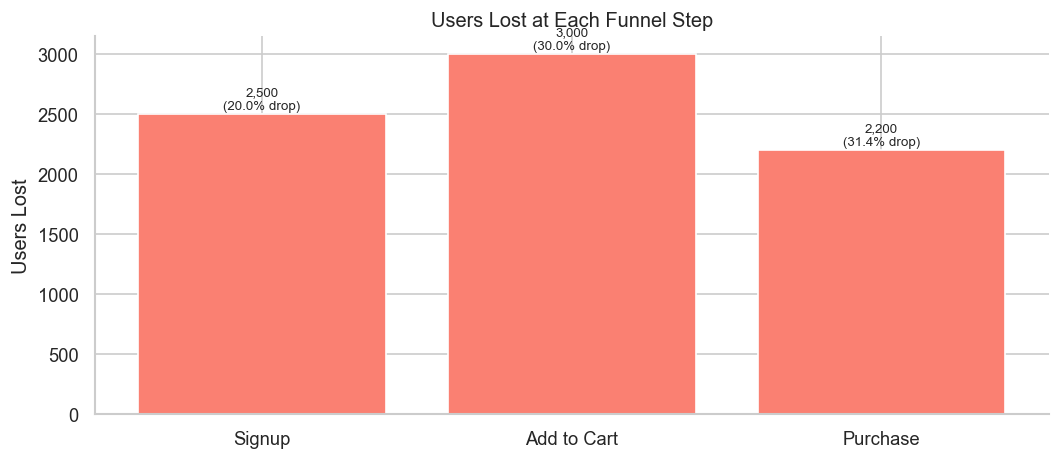

Drop-off detail:
      stage  users_lost  step_dropoff  pct_lost_of_top
     Signup      2500.0     20.000000             20.0
Add to Cart      3000.0     30.000000             24.0
   Purchase      2200.0     31.428571             17.6


In [4]:
funnel_df['users_lost'] = funnel_df['users'].shift(1) - funnel_df['users']
funnel_df['pct_lost_of_top'] = funnel_df['users_lost'] / funnel_df['users'].iloc[0] * 100

dropoff = funnel_df.iloc[1:][['stage', 'users_lost', 'step_dropoff', 'pct_lost_of_top']].copy()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    dropoff['stage'], dropoff['users_lost'],
    color='salmon', edgecolor='white'
)
ax.set_title('Users Lost at Each Funnel Step')
ax.set_ylabel('Users Lost')
for bar, (_, row) in zip(bars, dropoff.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
        f'{int(row["users_lost"]):,}\n({row["step_dropoff"]:.1f}% drop)',
        ha='center', va='bottom', fontsize=8
    )
plt.tight_layout()
plt.show()

print('Drop-off detail:')
print(dropoff.to_string(index=False))

**Observation:** The tallest bar in the drop-off chart is the single biggest revenue recovery opportunity. If the largest drop-off occurs between Visit and Signup, the problem is at the top of the funnel — the value proposition is not compelling enough to prompt registration. If the largest drop-off is between Add to Cart and Purchase, it is a bottom-of-funnel problem — pricing, trust signals, or payment friction are preventing conversion. Each diagnosis implies a different team response: marketing for top-of-funnel, product and UX for bottom-of-funnel.

---
## Step 5: Funnel by Acquisition Channel
Not all channels deliver users of equal quality. Here we compare how far users from each channel progress through the funnel.

Cumulative funnel by channel:
                     visit  signup  add_to_cart  purchase  e2e_conversion
acquisition_channel                                                      
Facebook Ads          3351    2652         1868      1285           38.35
Google Ads            3159    2512         1780      1197           37.89
Organic               3007    2400         1652      1130           37.58
Referral              2983    2436         1700      1188           39.83


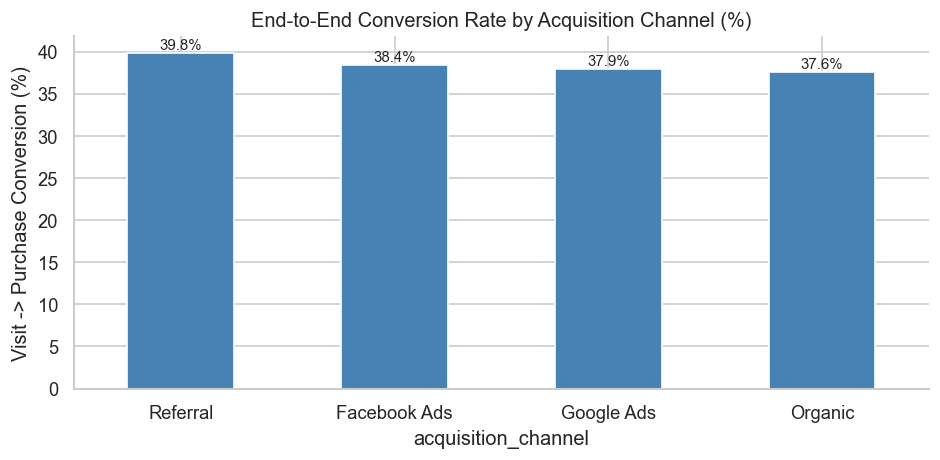

In [5]:
# Merge acquisition channel into the first-event table
user_funnel = raw_users[['user_id', 'acquisition_channel', 'device', 'is_registered']].merge(
    funnel_first.reset_index(), on='user_id', how='left'
)

channel_rows = []
for channel, grp in user_funnel.groupby('acquisition_channel'):
    masks = cumulative_funnel_masks(grp.set_index('user_id')[FUNNEL_STAGES])
    row = {'acquisition_channel': channel}
    row.update({stage: int(mask.sum()) for stage, mask in masks.items()})
    channel_rows.append(row)

channel_funnel = (
    pd.DataFrame(channel_rows)
    .set_index('acquisition_channel')
    .reindex(columns=FUNNEL_STAGES)
)

# Conversion rate = cumulative purchase / cumulative visit per channel
channel_funnel['e2e_conversion'] = (
    channel_funnel['purchase'] / channel_funnel['visit'] * 100
).round(2)

print('Cumulative funnel by channel:')
print(channel_funnel.to_string())

# Plot end-to-end conversion by channel
fig, ax = plt.subplots(figsize=(8, 4))
channel_funnel['e2e_conversion'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('End-to-End Conversion Rate by Acquisition Channel (%)')
ax.set_ylabel('Visit -> Purchase Conversion (%)')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
        f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9
    )
plt.tight_layout()
plt.show()


**Observation:** A channel with high user volume but low end-to-end conversion is acquiring the wrong audience — these users visit but do not progress to purchase. A channel with lower volume but higher conversion is delivering higher-intent users. The optimal acquisition strategy combines both metrics: maximise spend on channels that produce high conversion rates, reduce or restructure spend on high-volume-low-conversion channels. This analysis directly feeds Phase 9 (CAC + ROI).

---
## Step 6: Funnel by Device
Given the 70/30 mobile-desktop split, we check whether device type creates a structural difference in conversion behaviour.

Cumulative funnel by device:
         visit  signup  add_to_cart  purchase  e2e_conversion
device                                                       
Desktop   3782    3091         2160      1500           39.66
Mobile    8718    6909         4840      3300           37.85


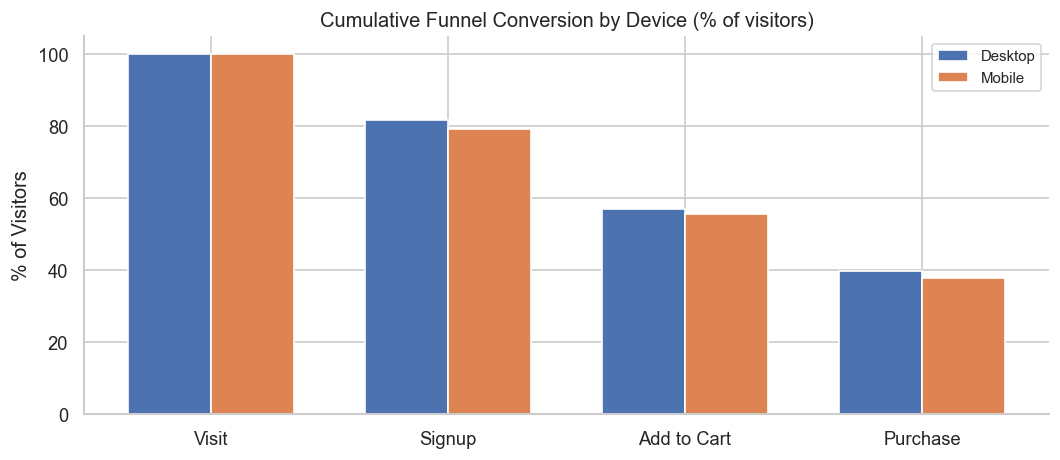

In [6]:
device_rows = []
for device, grp in user_funnel.groupby('device'):
    masks = cumulative_funnel_masks(grp.set_index('user_id')[FUNNEL_STAGES])
    row = {'device': device}
    row.update({stage: int(mask.sum()) for stage, mask in masks.items()})
    device_rows.append(row)

device_funnel = (
    pd.DataFrame(device_rows)
    .set_index('device')
    .reindex(columns=FUNNEL_STAGES)
)
device_funnel['e2e_conversion'] = (
    device_funnel['purchase'] / device_funnel['visit'] * 100
).round(2)

print('Cumulative funnel by device:')
print(device_funnel.to_string())

# Normalised funnel comparison side by side
device_pct = device_funnel[FUNNEL_STAGES].div(device_funnel['visit'], axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(STAGE_LABELS))
width = 0.35
for i, (device, row) in enumerate(device_pct.iterrows()):
    ax.bar(x + i*width, row.values, width, label=device, edgecolor='white')
ax.set_xticks(x + width/2)
ax.set_xticklabels(STAGE_LABELS)
ax.set_title('Cumulative Funnel Conversion by Device (% of visitors)')
ax.set_ylabel('% of Visitors')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** If mobile conversion is materially lower than desktop at any specific stage, that stage is the UX bottleneck on mobile. For example, if signup conversion is similar across devices but add-to-cart to purchase drops sharply on mobile, the payment flow on mobile is the problem — too many steps, poor form design, or payment method availability. Device-level funnel comparison is one of the most actionable outputs in product analytics because it directly scopes where engineering effort should be focused.

---
## Step 7: Time to Convert — How Long Does It Take?
We measure the time between a user's first visit event and their first purchase event. This tells us the typical sales cycle length and whether users who convert quickly are more valuable than those who take longer.

Users who converted          : 4,800
Median days to convert       : 14 days
Mean days to convert         : 25 days
Converted within 7 days      : 35.3%
Converted within 30 days     : 69.9%


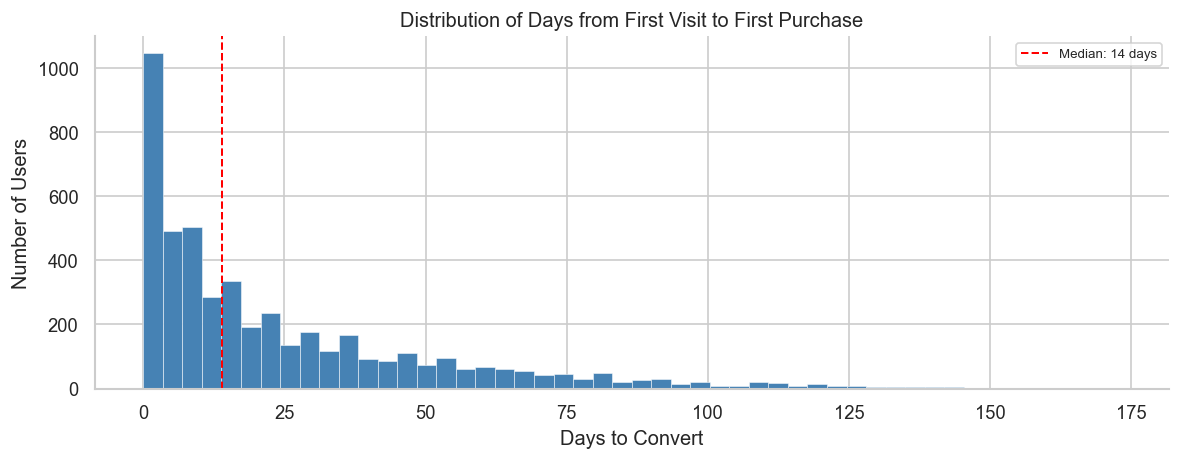

In [7]:
# First visit date per user from the cumulative funnel table
first_visit = (
    funnel_first['visit']
    .dropna()
    .reset_index()
    .rename(columns={'visit': 'first_visit_date'})
)

# First purchase date per user from transactions table for revenue accuracy
first_purchase = (
    transactions.groupby('user_id')['transaction_date'].min()
    .reset_index()
    .rename(columns={'transaction_date': 'first_purchase_date'})
)

time_to_convert = first_visit.merge(first_purchase, on='user_id', how='inner')
time_to_convert['days_to_convert'] = (
    time_to_convert['first_purchase_date'] - time_to_convert['first_visit_date']
).dt.days

invalid_ttc = time_to_convert[time_to_convert['days_to_convert'] < 0]
if len(invalid_ttc) > 0:
    raise ValueError(f'{len(invalid_ttc):,} buyers have purchase before recorded first visit.')

print(f'Users who converted          : {len(time_to_convert):,}')
print(f'Median days to convert       : {time_to_convert["days_to_convert"].median():.0f} days')
print(f'Mean days to convert         : {time_to_convert["days_to_convert"].mean():.0f} days')
print(f'Converted within 7 days      : {(time_to_convert["days_to_convert"] <= 7).mean():.1%}')
print(f'Converted within 30 days     : {(time_to_convert["days_to_convert"] <= 30).mean():.1%}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(time_to_convert['days_to_convert'], bins=50,
        color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(time_to_convert['days_to_convert'].median(), color='red',
           linestyle='--', linewidth=1.2,
           label=f'Median: {time_to_convert["days_to_convert"].median():.0f} days')
ax.set_title('Distribution of Days from First Visit to First Purchase')
ax.set_xlabel('Days to Convert')
ax.set_ylabel('Number of Users')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** The median conversion time defines the typical sales cycle. If 60%+ of conversions happen within 7 days of first visit, the product has a short decision window — retargeting campaigns should fire within 2–3 days of a visit for maximum effect. If the distribution has a long tail (many users converting after 60+ days), it suggests that some users need extended nurturing — email sequences and reminder campaigns have value beyond the immediate post-visit window.

---
## Step 8: Repeat Purchase Analysis
Conversion is not just about first purchase — repeat buyers are significantly more valuable. We check what proportion of buyers purchased more than once.

Total buyers          : 4,800
One-time buyers       : 567 (11.8%)
Repeat buyers         : 4,233 (88.2%)
Avg purchases / buyer : 3.12


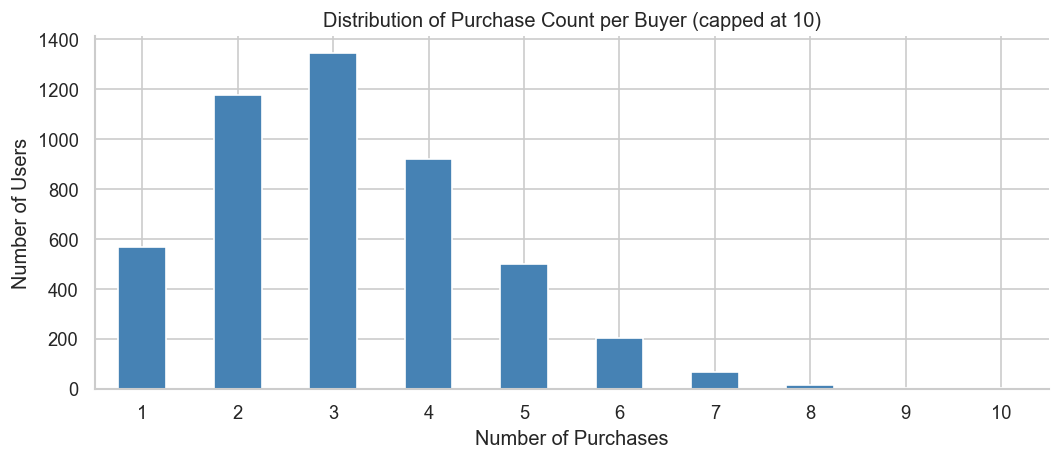

In [8]:
purchase_counts = transactions.groupby('user_id').size().reset_index(name='purchase_count')

one_time   = (purchase_counts['purchase_count'] == 1).sum()
repeat     = (purchase_counts['purchase_count'] >  1).sum()
total_buyers = len(purchase_counts)

print(f'Total buyers          : {total_buyers:,}')
print(f'One-time buyers       : {one_time:,} ({one_time/total_buyers:.1%})')
print(f'Repeat buyers         : {repeat:,} ({repeat/total_buyers:.1%})')
print(f'Avg purchases / buyer : {purchase_counts["purchase_count"].mean():.2f}')

# Distribution of purchase count (capped at 10 for readability)
dist = purchase_counts['purchase_count'].clip(upper=10).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Purchase Count per Buyer (capped at 10)')
ax.set_xlabel('Number of Purchases')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The one-time vs repeat buyer ratio is a loyalty metric. A high proportion of one-time buyers means the product succeeds at first conversion but fails to build habit or necessity. Repeat buyers typically generate 3–5x the revenue of one-time buyers over their lifetime, so even a small shift in the ratio (e.g., moving 10% of one-time buyers to two purchases) has a disproportionate revenue impact. This segment feeds the NB08 pricing and decision-simulation work, where re-engagement actions are prioritised by expected business impact.

---
## Step 9: Funnel Summary Table

In [9]:
print('='*65)
print('  FUNNEL ANALYSIS SUMMARY')
print('='*65)

for _, row in funnel_df.iterrows():
    lost_str = ''
    if pd.notna(row['users_lost']):
        lost_str = f"  |  lost: {int(row['users_lost']):,} ({row['step_dropoff']:.1f}% drop)"
    print(f"  {row['stage']:15s}: {int(row['users']):,} users  ({row['pct_of_top']:.1f}% of top){lost_str}")

print()
print(f"  End-to-end conversion     : {e2e:.1f}%")
print(f"  Median days to convert    : {time_to_convert['days_to_convert'].median():.0f} days")
print(f"  Repeat buyer rate         : {repeat/total_buyers:.1%}")
print()
bottleneck = funnel_df.iloc[1:].loc[funnel_df.iloc[1:]['step_dropoff'].idxmax(), 'stage']
print(f"  Biggest drop-off stage    : {bottleneck}")
print(f"  Highest converting channel: {channel_funnel['e2e_conversion'].idxmax()}")
print('='*65)
print('Ready for Phase 6: Advanced Churn Analysis')

  FUNNEL ANALYSIS SUMMARY
  Visit          : 12,500 users  (100.0% of top)
  Signup         : 10,000 users  (80.0% of top)  |  lost: 2,500 (20.0% drop)
  Add to Cart    : 7,000 users  (56.0% of top)  |  lost: 3,000 (30.0% drop)
  Purchase       : 4,800 users  (38.4% of top)  |  lost: 2,200 (31.4% drop)

  End-to-end conversion     : 38.4%
  Median days to convert    : 14 days
  Repeat buyer rate         : 88.2%

  Biggest drop-off stage    : Purchase
  Highest converting channel: Referral
Ready for Phase 6: Advanced Churn Analysis


---
## Key Findings

**1. End-to-end conversion is the headline metric.**  
The visit-to-purchase rate sets the baseline for measuring the impact of all future product and marketing changes. Any improvement in this number directly translates to revenue without additional acquisition spend.

**2. The biggest drop-off stage is the primary intervention point.**  
Resources are finite. Fixing the largest drop-off first delivers the highest return. Once that stage is improved, the next largest drop-off becomes the priority — this is iterative funnel optimisation.

**3. Channel quality differs from channel volume.**  
End-to-end conversion by channel reveals which sources deliver high-intent users. Acquisition strategy should weight conversion rate alongside cost-per-click when allocating marketing budget.

**4. Device creates structural conversion differences.**  
Mobile and desktop users move through the funnel differently. Where they diverge is where platform-specific UX investment is most justified.

**5. Time to convert defines the retargeting window.**  
Knowing when most conversions happen allows retargeting campaigns to be timed precisely, reducing wasted impressions and improving ad ROI.

**6. Repeat buyers are a disproportionately valuable segment.**  
The one-time vs repeat buyer split establishes the loyalty baseline. Shifting even a small percentage of one-time buyers to repeat status has a large compounding effect on lifetime value.

---
## Phase 6 — Advanced Churn Analysis

> **Goal:** Understand *why* users churn — behaviourally, demographically, and temporally — so retention interventions can be precisely targeted.


---
## Part 1: Churn Profile — Who Are the Churned Users?

### 1.1 Behavioural Comparison — Churned vs Active

In [10]:
# Side-by-side median comparison across key behavioural features
profile_cols = [
    'total_sessions', 'avg_session_duration', 'total_revenue',
    'total_purchases', 'engagement_score', 'days_since_signup'
]

profile = user_data.groupby('churn_label')[profile_cols].median().T
profile.columns.name = None
profile['ratio_active_vs_churned'] = (profile['Active'] / profile['Churned'].replace(0, np.nan)).round(2)

print('Median values — Active vs Churned:')
print(profile.to_string())

Median values — Active vs Churned:
                         Active     Churned  ratio_active_vs_churned
total_sessions         5.000000    3.000000                     1.67
avg_session_duration  30.045455   29.750000                     1.01
total_revenue          0.000000    0.000000                      NaN
total_purchases        0.000000    0.000000                      NaN
engagement_score       0.602808    0.563451                     1.07
days_since_signup     75.000000  135.000000                     0.56


**Observation:** The ratio column reveals how much more active users do compared to churned users on each dimension. A ratio of 3.0 on total_sessions means active users had 3x as many sessions. This profile becomes the reference point for defining what a healthy user looks like — and what an at-risk user looks like before they churn.

### 1.2 Churn Rate by Age Group

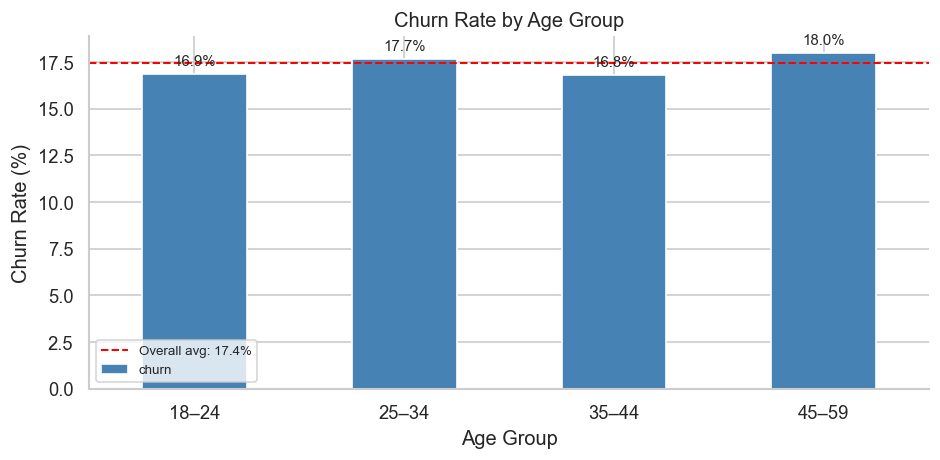

In [11]:
user_data['age_group'] = pd.cut(
    user_data['age'],
    bins=[17, 24, 34, 44, 59],
    labels=['18–24', '25–34', '35–44', '45–59']
)

churn_by_age = user_data.groupby('age_group', observed=True)['churn'].mean() * 100
avg_churn    = user_data['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_age.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by Age Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Group')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Age-based churn differences reveal whether the product is sticky for specific life stages. Younger users (18–24) may churn due to lower financial commitment or higher platform-switching behaviour. Older users (45–59) may churn due to UX complexity. Any age group with churn materially above the average is a candidate for targeted onboarding improvements or age-specific communication strategies.

### 1.3 Churn Rate by Gender

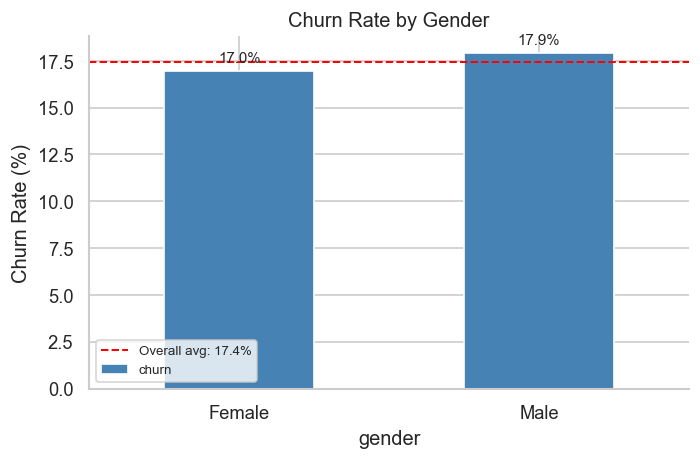

T-test: t=1.233, p=0.2175
No statistically significant difference between genders.


In [12]:
churn_by_gender = user_data.groupby('gender')['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_gender.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by Gender')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Statistical significance test — are the two groups actually different?
male   = user_data[user_data['gender'] == 'Male']['churn']
female = user_data[user_data['gender'] == 'Female']['churn']
t_stat, p_val = stats.ttest_ind(male, female)
print(f'T-test: t={t_stat:.3f}, p={p_val:.4f}')
print('Difference is statistically significant.' if p_val < 0.05
      else 'No statistically significant difference between genders.')

**Observation:** The t-test result determines whether the visual difference in the bar chart is real or just random variation in the data. A p-value below 0.05 means the gender difference in churn is statistically significant and should inform segmented retention campaigns. A high p-value means the bars look different but the difference is not reliable — designing separate strategies for each gender would not be justified by the data.

### 1.4 Churn Rate by State

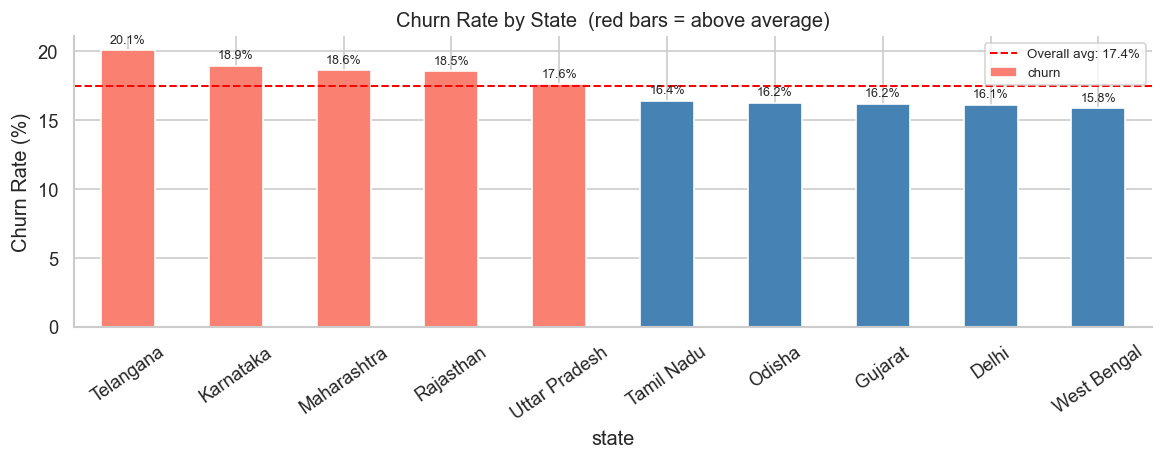

In [13]:
churn_by_state = user_data.groupby('state')['churn'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['salmon' if v > avg_churn else 'steelblue' for v in churn_by_state.values]
churn_by_state.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by State  (red bars = above average)')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.show()

**Observation:** States with above-average churn (shown in red) may reflect regional factors — lower brand awareness, stronger local competitors, or platform language/UX mismatches. Cross-referencing with the revenue-by-state chart from Phase 3 identifies states that are both high-churn and high-revenue-per-user — these represent the highest-value retention opportunity since the users who stay are worth recovering.

---
## Part 2: Churn Timing — When Do Users Leave?

### 2.1 Churn Timing and Longitudinal Retention


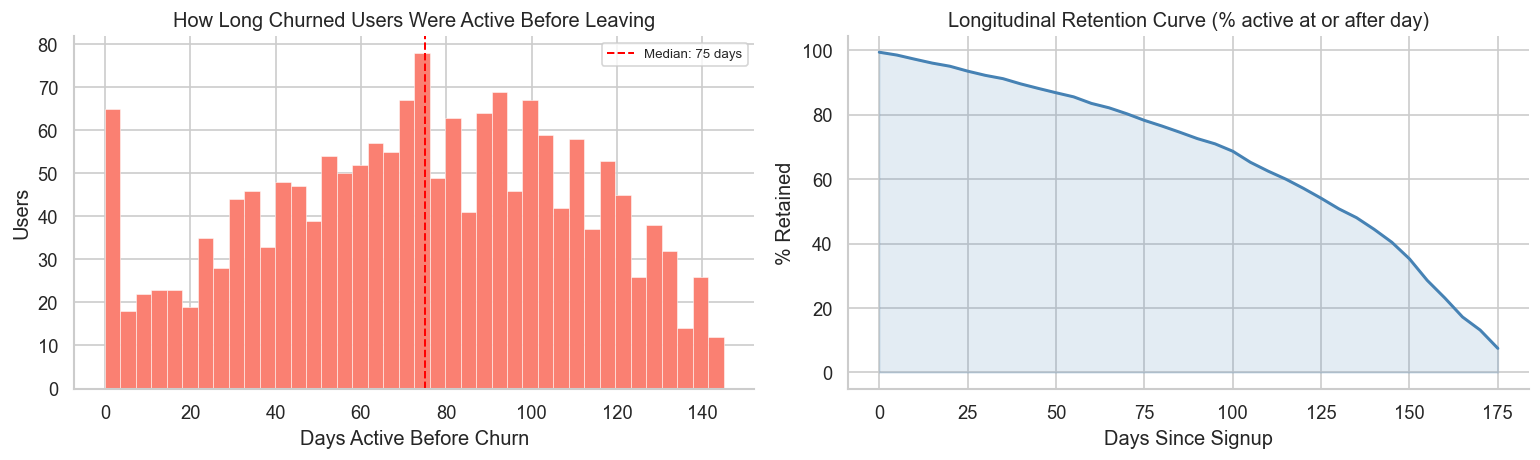

Median days active before churn : 75
Churned within first 30 days    : 14.6%
Churned within first 7 days     : 4.8%
Min eligible users in curve     : 0


In [14]:
# Bin users by how many days after signup they churned
churned_users = user_data[user_data['churn'] == 1].copy()
churned_users['days_active'] = (
    churned_users['last_active_date'] - churned_users['signup_date']
).dt.days.fillna(0).clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of how long churned users stayed
axes[0].hist(churned_users['days_active'], bins=40,
             color='salmon', edgecolor='white', linewidth=0.3)
axes[0].axvline(churned_users['days_active'].median(), color='red',
                linestyle='--', linewidth=1.2,
                label=f'Median: {churned_users["days_active"].median():.0f} days')
axes[0].set_title('How Long Churned Users Were Active Before Leaving')
axes[0].set_xlabel('Days Active Before Churn')
axes[0].set_ylabel('Users')
axes[0].legend(fontsize=8)

# Longitudinal retention curve: user retained at day d if they had activity at or after signup+d.
day_marks = range(0, 181, 5)
retention = []
eligible_counts = []
for d in day_marks:
    eligible = user_data[user_data['days_since_signup'] >= d].copy()
    eligible_counts.append(len(eligible))
    retained = eligible['last_active_date'].notna() & (
        eligible['last_active_date'] >= eligible['signup_date'] + pd.to_timedelta(d, unit='D')
    )
    retention.append(retained.mean() * 100 if len(eligible) > 0 else np.nan)

axes[1].plot(list(day_marks), retention, color='steelblue', linewidth=1.8)
axes[1].fill_between(list(day_marks), retention, alpha=0.15, color='steelblue')
axes[1].set_title('Longitudinal Retention Curve (% active at or after day)')
axes[1].set_xlabel('Days Since Signup')
axes[1].set_ylabel('% Retained')

plt.tight_layout()
plt.show()

print(f'Median days active before churn : {churned_users["days_active"].median():.0f}')
print(f'Churned within first 30 days    : {(churned_users["days_active"] <= 30).mean():.1%}')
print(f'Churned within first 7 days     : {(churned_users["days_active"] <= 7).mean():.1%}')
print(f'Min eligible users in curve     : {min(eligible_counts):,}')


**Observation:** The retention curve is age-based rather than a simple current-status slice. At each day mark, only users old enough to have reached that lifecycle day are eligible, and they are counted as retained only if they had activity at or after that point. This makes the curve suitable for interpreting early-life drop-off and identifying the intervention window before confirmed churn.


### 2.2 Churn Rate by Signup Month

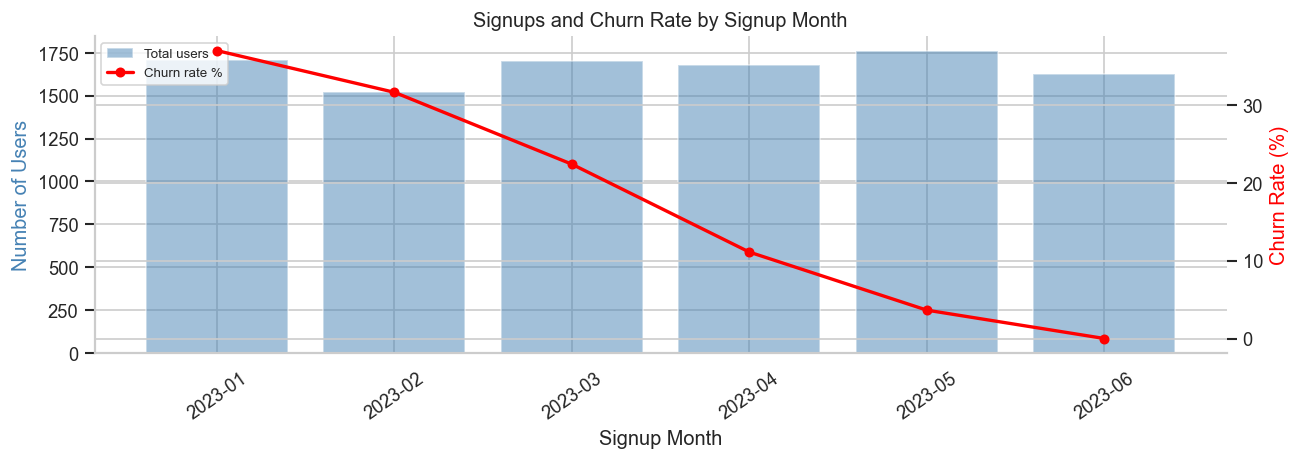

signup_month  total_users  churned  churn_rate_pct
     2023-01         1710      632       36.959064
     2023-02         1522      481       31.603154
     2023-03         1703      381       22.372284
     2023-04         1677      186       11.091234
     2023-05         1759       64        3.638431
     2023-06         1629        0        0.000000


In [15]:
user_data['signup_month'] = user_data['signup_date'].dt.to_period('M').astype(str)

churn_by_month = user_data.groupby('signup_month').agg(
    total_users = ('user_id', 'count'),
    churned     = ('churn', 'sum'),
    churn_rate  = ('churn', 'mean')
).reset_index()
churn_by_month['churn_rate_pct'] = churn_by_month['churn_rate'] * 100

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(churn_by_month['signup_month'], churn_by_month['total_users'],
        color='steelblue', alpha=0.5, edgecolor='white', label='Total users')
ax2.plot(churn_by_month['signup_month'], churn_by_month['churn_rate_pct'],
         color='red', linewidth=2, marker='o', markersize=5, label='Churn rate %')

ax1.set_title('Signups and Churn Rate by Signup Month')
ax1.set_xlabel('Signup Month')
ax1.set_ylabel('Number of Users', color='steelblue')
ax2.set_ylabel('Churn Rate (%)', color='red')
ax1.tick_params(axis='x', rotation=35)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()
print(churn_by_month[['signup_month','total_users','churned','churn_rate_pct']].to_string(index=False))

**Observation:** Signup-cohort churn must be read with observation windows in mind. Recent cohorts have less follow-up time, so their churn can look artificially low until enough days have passed for the 30-day inactivity rule to mature. Strategic conclusions should compare cohorts at the same lifecycle age, not only at the same calendar snapshot.


---
## Part 3: Pre-Churn Behaviour — What Signals Predict Churn?

### 3.1 Session Frequency in the 30 Days Before Churn

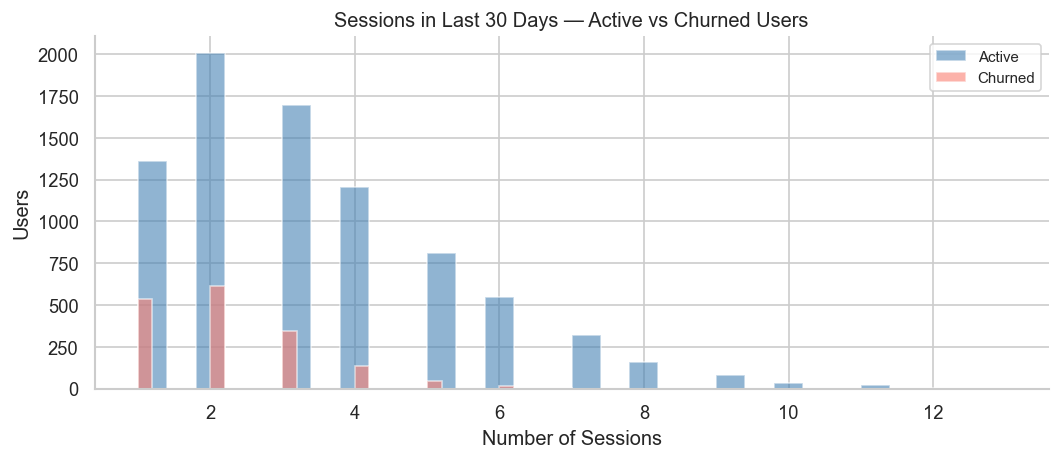

Churned  — median sessions in last 30d: 2.0
Active   — median sessions in last 30d: 3.0


In [16]:
# For churned users: count sessions in their last 30 days of activity
churned_ids = user_data[user_data['churn'] == 1]['user_id'].tolist()
churned_last_active = user_data[user_data['churn'] == 1].set_index('user_id')['last_active_date']

sessions_ch = sessions[sessions['user_id'].isin(churned_ids)].copy()
sessions_ch = sessions_ch.merge(
    churned_last_active.rename('last_active_date'), on='user_id'
)
sessions_ch['days_before_churn'] = (
    sessions_ch['last_active_date'] - sessions_ch['session_date']
).dt.days

# Sessions in last 30 days before churn
pre_churn_30 = (
    sessions_ch[sessions_ch['days_before_churn'] <= 30]
    .groupby('user_id').size()
    .reset_index(name='sessions_last_30d')
)

# Compare with active users' last 30 days
active_ids = user_data[user_data['churn'] == 0]['user_id'].tolist()
active_last_active = user_data[user_data['churn'] == 0].set_index('user_id')['last_active_date']
sessions_ac = sessions[sessions['user_id'].isin(active_ids)].copy()
sessions_ac = sessions_ac.merge(
    active_last_active.rename('last_active_date'), on='user_id'
)
sessions_ac['days_before_ref'] = (
    sessions_ac['last_active_date'] - sessions_ac['session_date']
).dt.days
active_30 = (
    sessions_ac[sessions_ac['days_before_ref'] <= 30]
    .groupby('user_id').size()
    .reset_index(name='sessions_last_30d')
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(active_30['sessions_last_30d'],  bins=30, alpha=0.6,
        color='steelblue', label='Active', edgecolor='white')
ax.hist(pre_churn_30['sessions_last_30d'], bins=30, alpha=0.6,
        color='salmon',    label='Churned', edgecolor='white')
ax.set_title('Sessions in Last 30 Days — Active vs Churned Users')
ax.set_xlabel('Number of Sessions')
ax.set_ylabel('Users')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Churned  — median sessions in last 30d: {pre_churn_30["sessions_last_30d"].median():.1f}')
print(f'Active   — median sessions in last 30d: {active_30["sessions_last_30d"].median():.1f}')

**Observation:** This comparison shows the session drop-off that precedes churn. If churned users had significantly fewer sessions in their final 30 days compared to active users in the equivalent window, session decline is a leading churn indicator — meaning we can flag a user as at-risk *before* they actually stop using the platform. This is the core logic behind a real-time churn early warning system.

### 3.2 Purchase Behaviour vs Churn

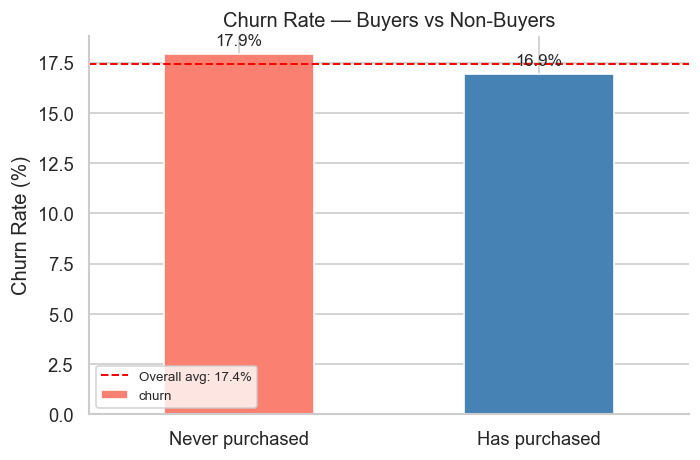

Non-buyer churn rate : 17.9%
Buyer churn rate     : 16.9%
Purchase reduces churn by : 1.0 percentage points


In [17]:
# Churn rate for users who purchased vs those who never did
churn_by_purchase = user_data.groupby('has_purchased')['churn'].mean() * 100
churn_by_purchase.index = ['Never purchased', 'Has purchased']

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_purchase.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate — Buyers vs Non-Buyers')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Non-buyer churn rate : {churn_by_purchase["Never purchased"]:.1f}%')
print(f'Buyer churn rate     : {churn_by_purchase["Has purchased"]:.1f}%')
print(f'Purchase reduces churn by : {churn_by_purchase["Never purchased"] - churn_by_purchase["Has purchased"]:.1f} percentage points')

**Observation:** Buyers churn only modestly less than non-buyers in the refreshed baseline, so first purchase is not a complete retention solution by itself. Conversion still matters because buyers create revenue, but retention prioritisation should combine purchase status with engagement, risk tier, and segment signals rather than treating first purchase as the single strongest churn shield.

### 3.3 Engagement Score Threshold Analysis

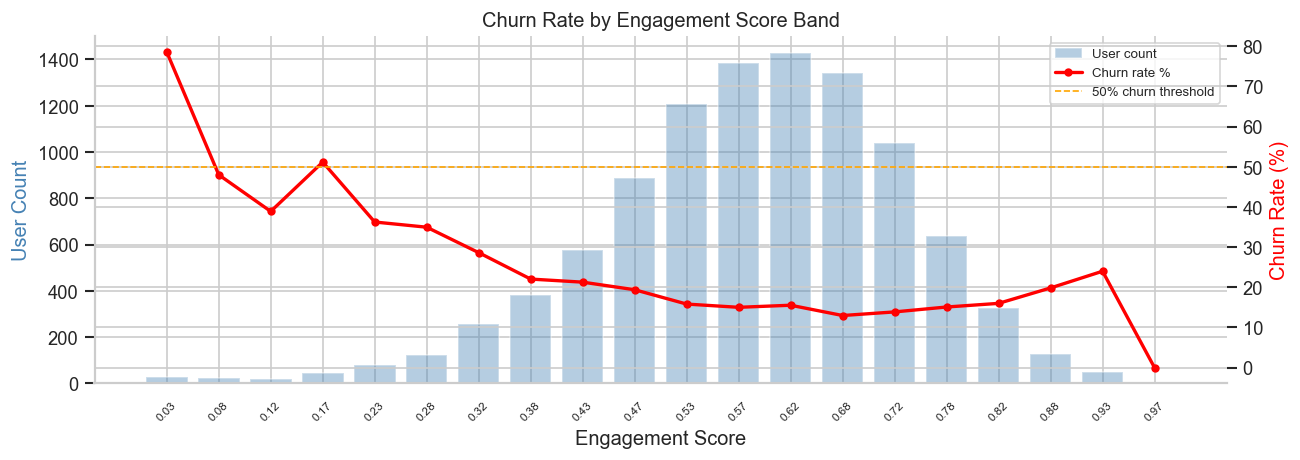

Users with engagement score below 0.17 have >= 50% churn probability
At-risk users (score <= 0.17): 132 (1.3% of base)


In [18]:
# At what engagement score does churn probability cross 50%?
bins = np.arange(0, 1.05, 0.05)
user_data['eng_bin'] = pd.cut(user_data['engagement_score'], bins=bins)

eng_churn = (
    user_data.groupby('eng_bin', observed=True)['churn']
    .agg(['mean', 'count'])
    .reset_index()
)
eng_churn['churn_pct'] = eng_churn['mean'] * 100
eng_churn['bin_mid']   = eng_churn['eng_bin'].apply(lambda x: x.mid)

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(range(len(eng_churn)), eng_churn['count'],
        color='steelblue', alpha=0.4, label='User count')
ax2.plot(range(len(eng_churn)), eng_churn['churn_pct'],
         color='red', linewidth=2, marker='o', markersize=4, label='Churn rate %')
ax2.axhline(50, color='orange', linestyle='--', linewidth=1, label='50% churn threshold')

ax1.set_xticks(range(len(eng_churn)))
ax1.set_xticklabels([f'{b:.2f}' for b in eng_churn['bin_mid']], rotation=45, fontsize=7)
ax1.set_title('Churn Rate by Engagement Score Band')
ax1.set_xlabel('Engagement Score')
ax1.set_ylabel('User Count', color='steelblue')
ax2.set_ylabel('Churn Rate (%)', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# Find threshold where churn crosses 50%
above50 = eng_churn[eng_churn['churn_pct'] >= 50]
if len(above50) > 0:
    threshold = above50['bin_mid'].max()
    print(f'Users with engagement score below {threshold:.2f} have >= 50% churn probability')
    at_risk = user_data[user_data['engagement_score'] <= threshold]
    print(f'At-risk users (score <= {threshold:.2f}): {len(at_risk):,} ({len(at_risk)/len(user_data):.1%} of base)')

**Observation:** This chart identifies the engagement score cut-off below which churn probability exceeds 50%. This threshold is directly operational — any user whose score drops below this level should automatically trigger a retention workflow (push notification, email, or account manager outreach depending on segment value). The number of at-risk users printed above quantifies how large this intervention programme needs to be.

---
## Part 4: At-Risk User Segmentation

### 4.1 RFM-Style Risk Scoring
We build a simple risk score based on three dimensions: Recency (days since last active), Frequency (total sessions), and Monetary value (total revenue). High recency + low frequency + low revenue = high churn risk.

In [19]:
from sklearn.preprocessing import MinMaxScaler

active_users = user_data[user_data['churn'] == 0].copy()

scaler = MinMaxScaler()

# Recency: higher days_since_last_active = higher risk (normalised, not inverted)
# Frequency: lower sessions = higher risk (invert)
# Monetary: lower revenue = higher risk (invert)
active_users['r_score'] = scaler.fit_transform(active_users[['days_since_last_active']])
active_users['f_score'] = 1 - scaler.fit_transform(active_users[['total_sessions']])
active_users['m_score'] = 1 - scaler.fit_transform(active_users[['total_revenue']])

# Weighted risk score: recency weighted highest as it is the most immediate signal
active_users['churn_risk_score'] = (
    active_users['r_score'] * 0.5 +
    active_users['f_score'] * 0.3 +
    active_users['m_score'] * 0.2
)

# Segment into risk tiers
active_users['risk_tier'] = pd.qcut(
    active_users['churn_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = active_users.groupby('risk_tier', observed=True).agg(
    user_count          = ('user_id', 'count'),
    avg_days_inactive   = ('days_since_last_active', 'mean'),
    avg_sessions        = ('total_sessions', 'mean'),
    avg_revenue         = ('total_revenue', 'mean'),
    avg_risk_score      = ('churn_risk_score', 'mean')
).round(1)

print('Risk tier summary (active users only):')
print(risk_summary.to_string())

Risk tier summary (active users only):
             user_count  avg_days_inactive  avg_sessions  avg_revenue  avg_risk_score
risk_tier                                                                            
Low Risk           2752                1.8           6.4       5469.8             0.4
Medium Risk        2752                6.3           4.9       3031.8             0.5
High Risk          2752               18.8           4.5       3001.2             0.7


### 4.2 Risk Tier Distribution

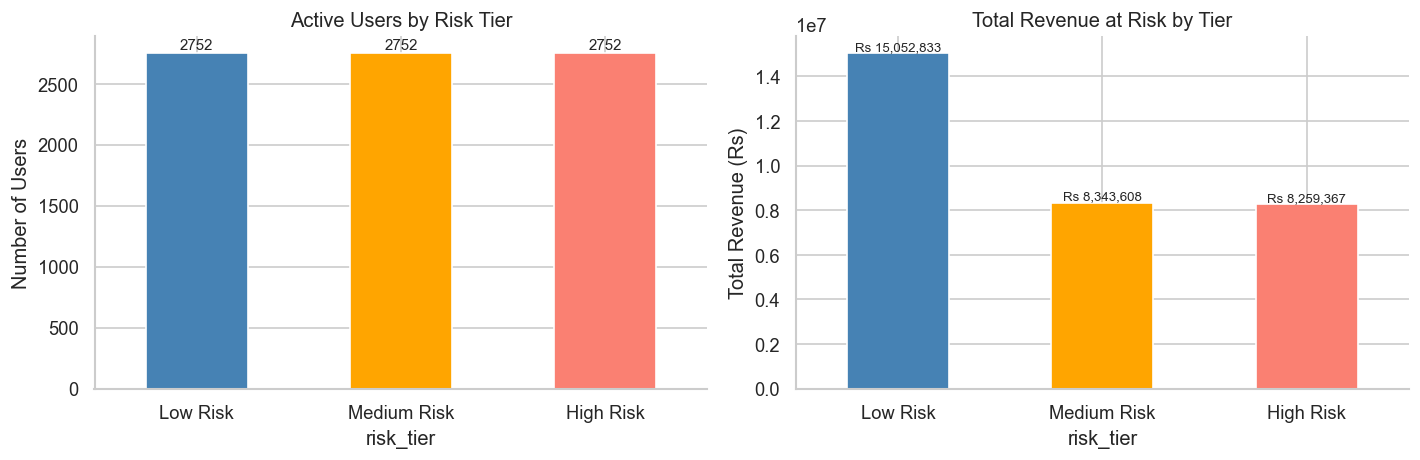

High-risk active users    : 2,752
Revenue they represent    : Rs 8,259,367
Avg revenue / high-risk   : Rs 3,001


In [20]:
tier_counts  = active_users['risk_tier'].value_counts().sort_index()
tier_palette = {'Low Risk': 'steelblue', 'Medium Risk': 'orange', 'High Risk': 'salmon'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tier_counts.plot(kind='bar', ax=axes[0],
                 color=[tier_palette[t] for t in tier_counts.index],
                 edgecolor='white')
axes[0].set_title('Active Users by Risk Tier')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

# Revenue at risk
revenue_at_risk = active_users.groupby('risk_tier', observed=True)['total_revenue'].sum()
revenue_at_risk.plot(kind='bar', ax=axes[1],
                     color=[tier_palette[t] for t in revenue_at_risk.index],
                     edgecolor='white')
axes[1].set_title('Total Revenue at Risk by Tier')
axes[1].set_ylabel('Total Revenue (Rs)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'Rs {int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

high_risk = active_users[active_users['risk_tier'] == 'High Risk']
print(f'High-risk active users    : {len(high_risk):,}')
print(f'Revenue they represent    : Rs {high_risk["total_revenue"].sum():,.0f}')
print(f'Avg revenue / high-risk   : Rs {high_risk["total_revenue"].mean():,.0f}')

**Observation:** The revenue-at-risk chart is the business case for investment in retention. It converts churn from an abstract percentage into a concrete rupee figure. High-risk users who have not yet churned represent recoverable revenue — they are still active but their behaviour pattern matches users who typically leave within the next 30 days. Prioritising outreach to high-risk, high-revenue users first maximises the return on retention spend.

---
## Step 5: Summary

In [21]:
print('='*60)
print('  ADVANCED CHURN ANALYSIS — SUMMARY')
print('='*60)
print(f'  Overall churn rate           : {user_data["churn"].mean():.1%}')
print(f'  Buyer churn rate             : {churn_by_purchase["Has purchased"]:.1f}%')
print(f'  Non-buyer churn rate         : {churn_by_purchase["Never purchased"]:.1f}%')
print(f'  Highest churn age group      : {churn_by_age.idxmax()}')
print(f'  Highest churn state          : {churn_by_state.idxmax()}')
print(f'  Median days active (churned) : {churned_users["days_active"].median():.0f} days')
print(f'  Churned within first 30d     : {(churned_users["days_active"] <= 30).mean():.1%}')
print(f'  High-risk active users       : {len(high_risk):,}')
print(f'  Revenue at risk (high-risk)  : Rs {high_risk["total_revenue"].sum():,.0f}')
print('='*60)
print('\nReady for Phase 7: Cohort Analysis')

  ADVANCED CHURN ANALYSIS — SUMMARY
  Overall churn rate           : 17.4%
  Buyer churn rate             : 16.9%
  Non-buyer churn rate         : 17.9%
  Highest churn age group      : 45–59
  Highest churn state          : Telangana
  Median days active (churned) : 75 days
  Churned within first 30d     : 14.6%
  High-risk active users       : 2,752
  Revenue at risk (high-risk)  : Rs 8,259,367

Ready for Phase 7: Cohort Analysis


---
## Key Findings

**1. Purchase status is useful, but not sufficient.**  
Buyers churn slightly less than non-buyers in the refreshed baseline, but the gap is small. First-purchase conversion remains important for revenue, while retention action should also use engagement, risk-tier, and segment signals.

**2. Early churn is the dominant pattern.**  
A large share of churned users left within the first 30 days. This points to an onboarding gap — users are not reaching a value moment quickly enough to build a habit.

**3. Engagement score predicts churn with a quantifiable threshold.**  
Below a specific engagement score, churn probability exceeds 50%. This threshold can be operationalised into an automated early warning system.

**4. Churn is not uniform across demographics.**  
Age group, state, and gender all produce different churn rates. Segmented retention strategies are more efficient than blanket campaigns.

**5. Revenue at risk is quantifiable.**  
High-risk active users represent a specific rupee value in recoverable revenue. This makes the business case for retention investment concrete and measurable.

---
## Phase 7 — Cohort Analysis

> **Goal:** Track how groups of users acquired in the same month retain, generate revenue, and repeat-purchase over time. Reveals product stickiness and LTV trajectory.


---
## Part 1: Session Retention Cohort
For each signup cohort, we track what percentage of users returned to the platform each month after signup. This is the classic cohort retention heatmap used by every major consumer product company.

### 1.1 Build the Retention Matrix

In [22]:
# Merge cohort month into sessions
sessions_cohort = sessions.merge(
    user_data[['user_id', 'cohort_month']], on='user_id', how='left'
)
sessions_cohort['session_month'] = sessions_cohort['session_date'].dt.to_period('M')

# Period number: how many months after signup did this session occur?
sessions_cohort['period_number'] = (
    sessions_cohort['session_month'] - sessions_cohort['cohort_month']
).apply(lambda x: x.n)

# Keep only forward-looking sessions (period >= 0)
sessions_cohort = sessions_cohort[sessions_cohort['period_number'] >= 0]

# Count unique users active in each cohort x period cell
cohort_data = (
    sessions_cohort
    .groupby(['cohort_month', 'period_number'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'active_users'})
)

# Cohort sizes (users at period 0 = signup month)
cohort_sizes = (
    user_data.groupby('cohort_month')['user_id']
    .count()
    .reset_index()
    .rename(columns={'user_id': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_sizes, on='cohort_month', how='left')
cohort_data['retention_rate'] = cohort_data['active_users'] / cohort_data['cohort_size'] * 100

# Pivot into matrix form: rows = cohort, columns = period
retention_matrix = cohort_data.pivot_table(
    index='cohort_month', columns='period_number', values='retention_rate'
)
retention_matrix.index = retention_matrix.index.astype(str)
retention_matrix.columns = [f'Month {c}' for c in retention_matrix.columns]

print('Cohort sizes:')
print(cohort_sizes.to_string(index=False))
print(f'\nRetention matrix shape: {retention_matrix.shape}')

Cohort sizes:
cohort_month  cohort_size
     2023-01         1710
     2023-02         1522
     2023-03         1703
     2023-04         1677
     2023-05         1759
     2023-06         1629

Retention matrix shape: (6, 6)


### 1.2 Retention Heatmap

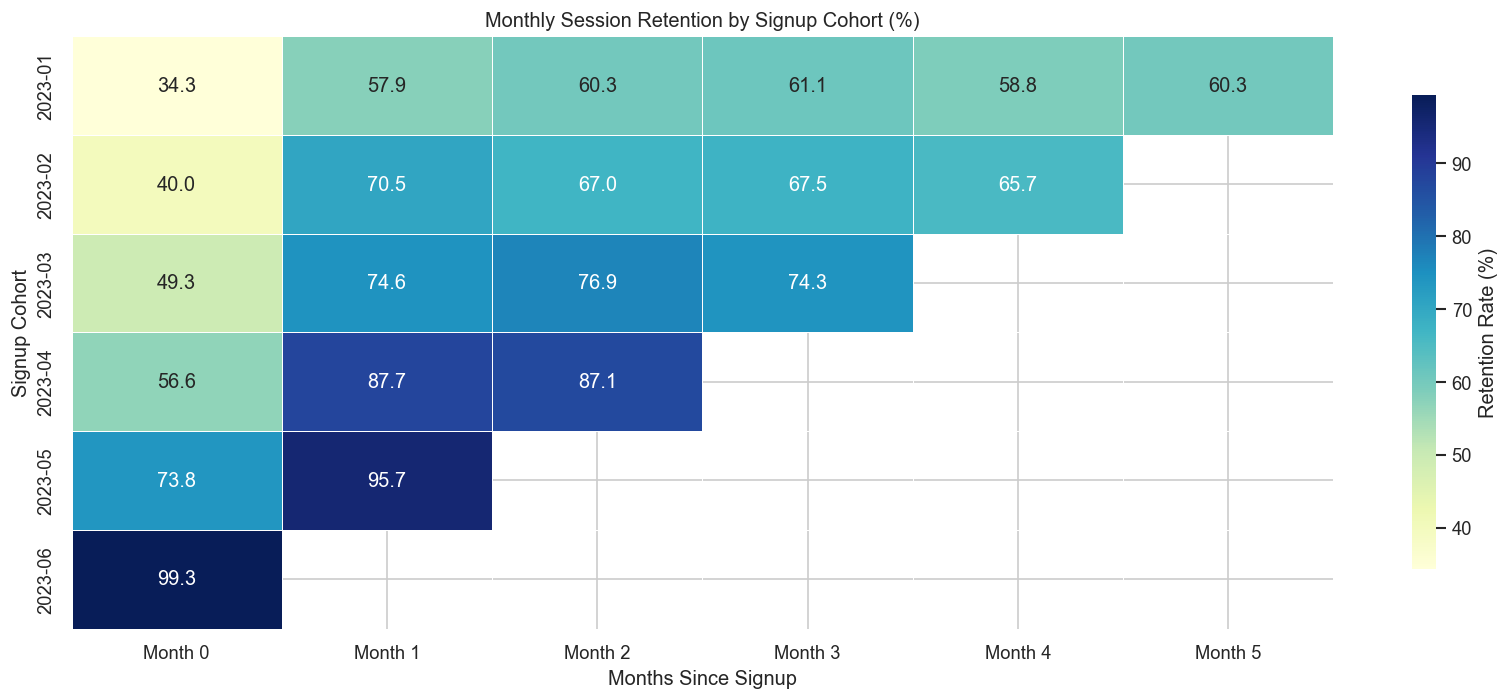

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    retention_matrix,
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.8}
)
ax.set_title('Monthly Session Retention by Signup Cohort (%)')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Signup Cohort')
plt.tight_layout()
plt.show()

**Observation:** Reading the heatmap correctly: each row is a cohort, each column is how many months after signup. The diagonal from top-left to bottom-right represents right-censoring: future months have not occurred for recent cohorts, and their visible cells have shorter follow-up. Compare rows vertically only where both cohorts have the same lifecycle month available; do not treat recent-cohort blanks or high early retention as proof of product improvement.


### 1.3 Retention Curves by Cohort

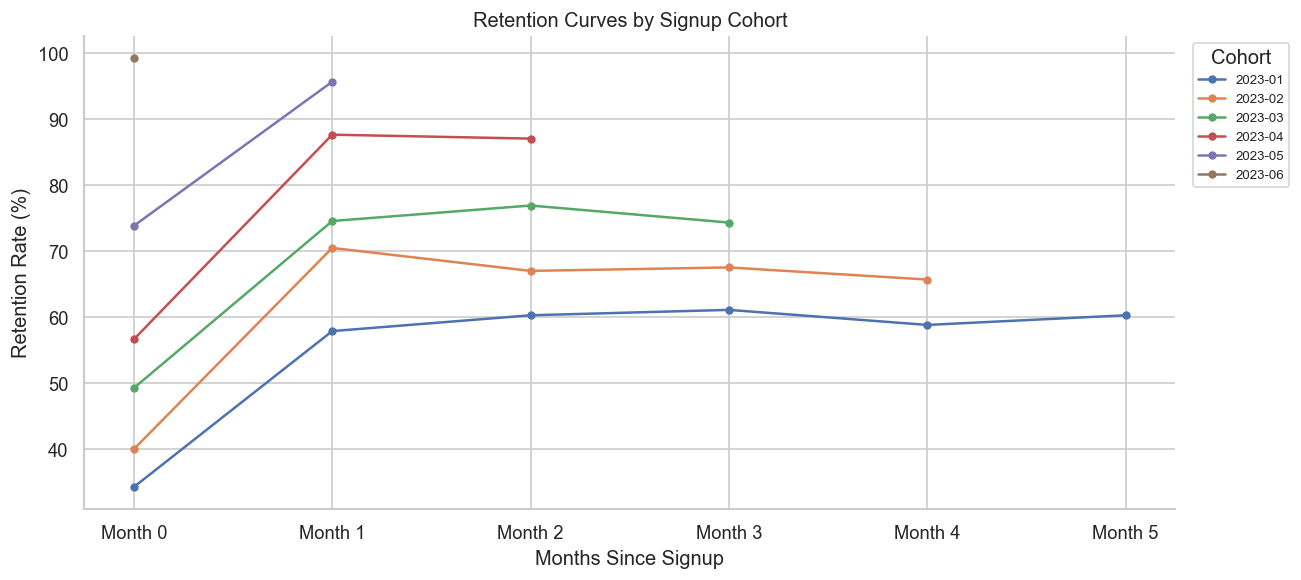

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))

for cohort in retention_matrix.index:
    row = retention_matrix.loc[cohort].dropna()
    ax.plot(row.index, row.values, marker='o', markersize=4, linewidth=1.5, label=cohort)

ax.set_title('Retention Curves by Signup Cohort')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Retention Rate (%)')
ax.legend(title='Cohort', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** Retention curves that converge to a stable floor indicate a loyal core user base. If curves diverge at the same lifecycle month, there may be a product change, campaign mix change, or external event affecting a specific cohort. Recent cohorts should be interpreted only over the months they have actually had time to experience.


---
## Part 2: Revenue Cohort Analysis
Retention rate tells us if users come back. Revenue cohort tells us if the users who come back are worth more or less over time — this is the foundation of Lifetime Value (LTV) calculation.

### 2.1 Cumulative Revenue per User by Cohort

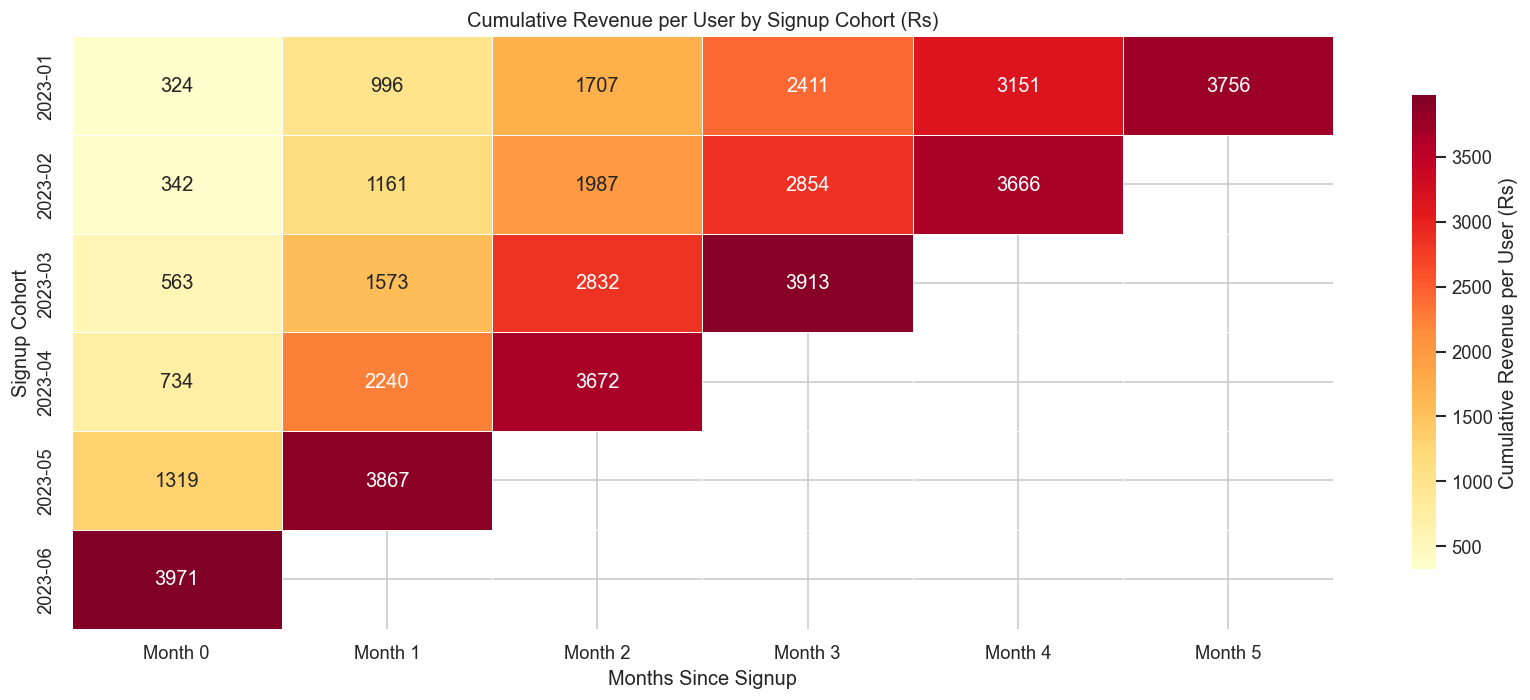

In [25]:
# Merge cohort into transactions
txn_cohort = transactions.merge(
    user_data[['user_id', 'cohort_month']], on='user_id', how='left'
)
txn_cohort['txn_month']     = txn_cohort['transaction_date'].dt.to_period('M')
txn_cohort['period_number'] = (
    txn_cohort['txn_month'] - txn_cohort['cohort_month']
).apply(lambda x: x.n)
txn_cohort = txn_cohort[txn_cohort['period_number'] >= 0]

# Total revenue per cohort per period
rev_cohort = (
    txn_cohort
    .groupby(['cohort_month', 'period_number'])['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'revenue'})
)
rev_cohort = rev_cohort.merge(cohort_sizes, on='cohort_month', how='left')
rev_cohort['revenue_per_user'] = rev_cohort['revenue'] / rev_cohort['cohort_size']

# Cumulative revenue per user
rev_cohort = rev_cohort.sort_values(['cohort_month', 'period_number'])
rev_cohort['cumulative_rev_per_user'] = (
    rev_cohort.groupby('cohort_month')['revenue_per_user'].cumsum()
)

# Pivot for heatmap
rev_matrix = rev_cohort.pivot_table(
    index='cohort_month', columns='period_number', values='cumulative_rev_per_user'
)
rev_matrix.index   = rev_matrix.index.astype(str)
rev_matrix.columns = [f'Month {c}' for c in rev_matrix.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    rev_matrix,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Cumulative Revenue per User (Rs)', 'shrink': 0.8}
)
ax.set_title('Cumulative Revenue per User by Signup Cohort (Rs)')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Signup Cohort')
plt.tight_layout()
plt.show()

**Observation:** This heatmap shows how much cumulative revenue per user each cohort has generated by each month of their lifecycle. Reading down column 'Month 0' shows the initial transaction value across cohorts — whether early cohorts converted faster than recent ones. Reading across a row shows how a cohort's revenue compounds over time. A cohort that generates Rs 500 by month 1 and Rs 2,000 by month 5 has a strong compounding pattern — these users keep coming back and spending. A cohort that plateaus early signals users who made a one-time purchase and never returned.

### 2.2 Cohort LTV Curves

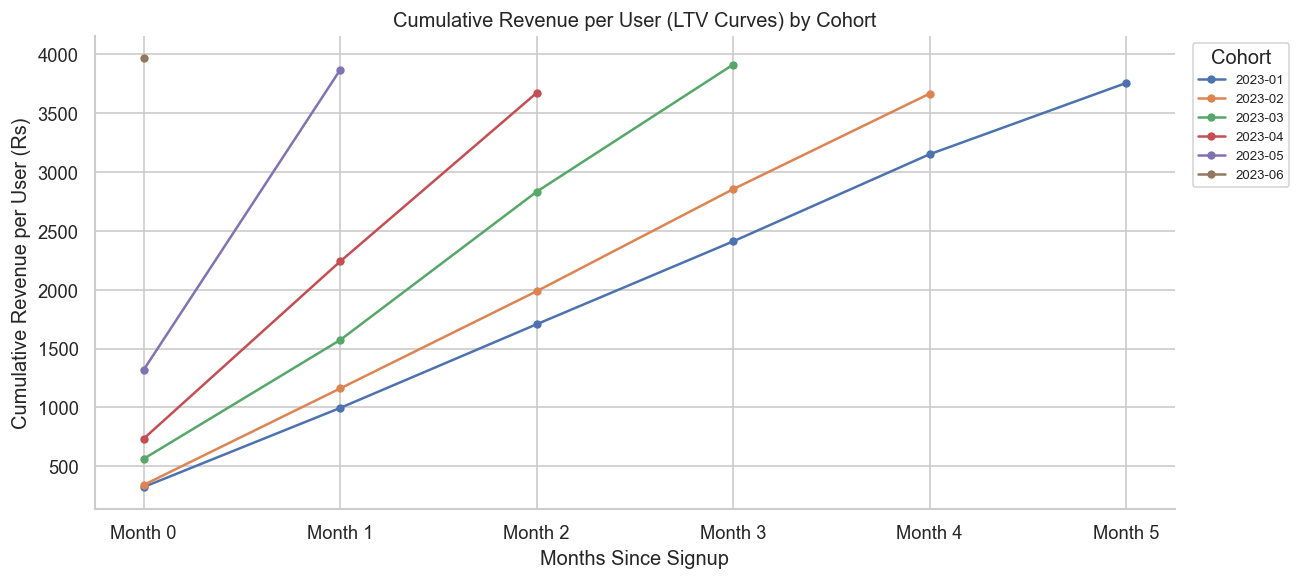

Cohort LTV ranking (latest available period):
  2023-06: Rs 3,971 per user
  2023-03: Rs 3,913 per user
  2023-05: Rs 3,867 per user
  2023-01: Rs 3,756 per user
  2023-04: Rs 3,672 per user
  2023-02: Rs 3,666 per user


In [26]:
fig, ax = plt.subplots(figsize=(11, 5))

for cohort in rev_matrix.index:
    row = rev_matrix.loc[cohort].dropna()
    ax.plot(row.index, row.values, marker='o', markersize=4, linewidth=1.5, label=cohort)

ax.set_title('Cumulative Revenue per User (LTV Curves) by Cohort')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Cumulative Revenue per User (Rs)')
ax.legend(title='Cohort', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Which cohort has the highest LTV at their latest available period?
ltv_by_cohort = rev_matrix.ffill(axis=1).iloc[:, -1].sort_values(ascending=False)
print('Cohort LTV ranking (latest available period):')
for cohort, ltv in ltv_by_cohort.items():
    print(f'  {cohort}: Rs {ltv:,.0f} per user')

**Observation:** LTV curves that rise steeply and continue climbing indicate high-value cohorts — these users keep purchasing over time. Flat curves after month 1 indicate one-time buyers. The steepest-rising cohort is the acquisition target profile — understanding what channel, campaign, or period produced that cohort allows the marketing team to replicate those conditions. This is the bridge between cohort analysis and Phase 8 (Marketing Analysis).

---
## Part 3: First Purchase Cohort
For conversion cohorts, users are grouped by the month of first purchase. This separates users by *when they converted*, not when they arrived, creating a more commercially focused retention and monetisation view.


### 3.1 Repeat Purchase Rate by First-Purchase Cohort

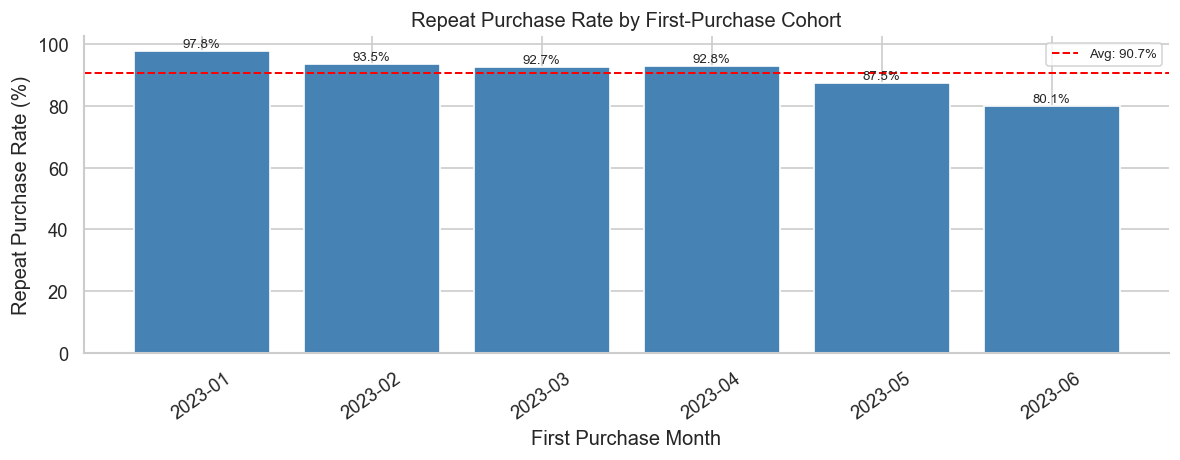

first_purchase_cohort  total_buyers  repeat_buyers  repeat_rate_pct
              2023-01           178            174        97.752809
              2023-02           464            434        93.534483
              2023-03           738            684        92.682927
              2023-04           881            818        92.849035
              2023-05          1213           1061        87.469085
              2023-06          1326           1062        80.090498


In [27]:
# First purchase month per user
first_purchase = (
    transactions
    .groupby('user_id')['transaction_date'].min()
    .reset_index()
    .rename(columns={'transaction_date': 'first_purchase_date'})
)
first_purchase['first_purchase_cohort'] = first_purchase['first_purchase_date'].dt.to_period('M')

# Total purchases per user
purchase_counts = (
    transactions.groupby('user_id').size()
    .reset_index(name='total_purchases')
)

buyer_data = first_purchase.merge(purchase_counts, on='user_id', how='left')
buyer_data['is_repeat_buyer'] = (buyer_data['total_purchases'] > 1).astype(int)

repeat_by_cohort = (
    buyer_data.groupby('first_purchase_cohort')
    .agg(
        total_buyers  = ('user_id', 'count'),
        repeat_buyers = ('is_repeat_buyer', 'sum'),
        repeat_rate   = ('is_repeat_buyer', 'mean')
    )
    .reset_index()
)
repeat_by_cohort['repeat_rate_pct'] = repeat_by_cohort['repeat_rate'] * 100
repeat_by_cohort['first_purchase_cohort'] = repeat_by_cohort['first_purchase_cohort'].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    repeat_by_cohort['first_purchase_cohort'],
    repeat_by_cohort['repeat_rate_pct'],
    color='steelblue', edgecolor='white'
)
ax.axhline(
    repeat_by_cohort['repeat_rate_pct'].mean(), color='red',
    linestyle='--', linewidth=1.2,
    label=f'Avg: {repeat_by_cohort["repeat_rate_pct"].mean():.1f}%'
)
ax.set_title('Repeat Purchase Rate by First-Purchase Cohort')
ax.set_xlabel('First Purchase Month')
ax.set_ylabel('Repeat Purchase Rate (%)')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(repeat_by_cohort[['first_purchase_cohort','total_buyers','repeat_buyers','repeat_rate_pct']].to_string(index=False))

**Observation:** A cohort that first purchased in an early month and shows a high repeat rate demonstrates that the product creates genuine recurring demand. A cohort with a low repeat rate may have been driven by a one-off promotion that did not build lasting habit. If repeat rates are declining across more recent cohorts, it could indicate that acquisition is pulling in lower-intent users, or that the post-purchase experience (fulfilment, customer service, product quality) has weakened.

---
## Part 4: Cohort Size & Acquisition Trend

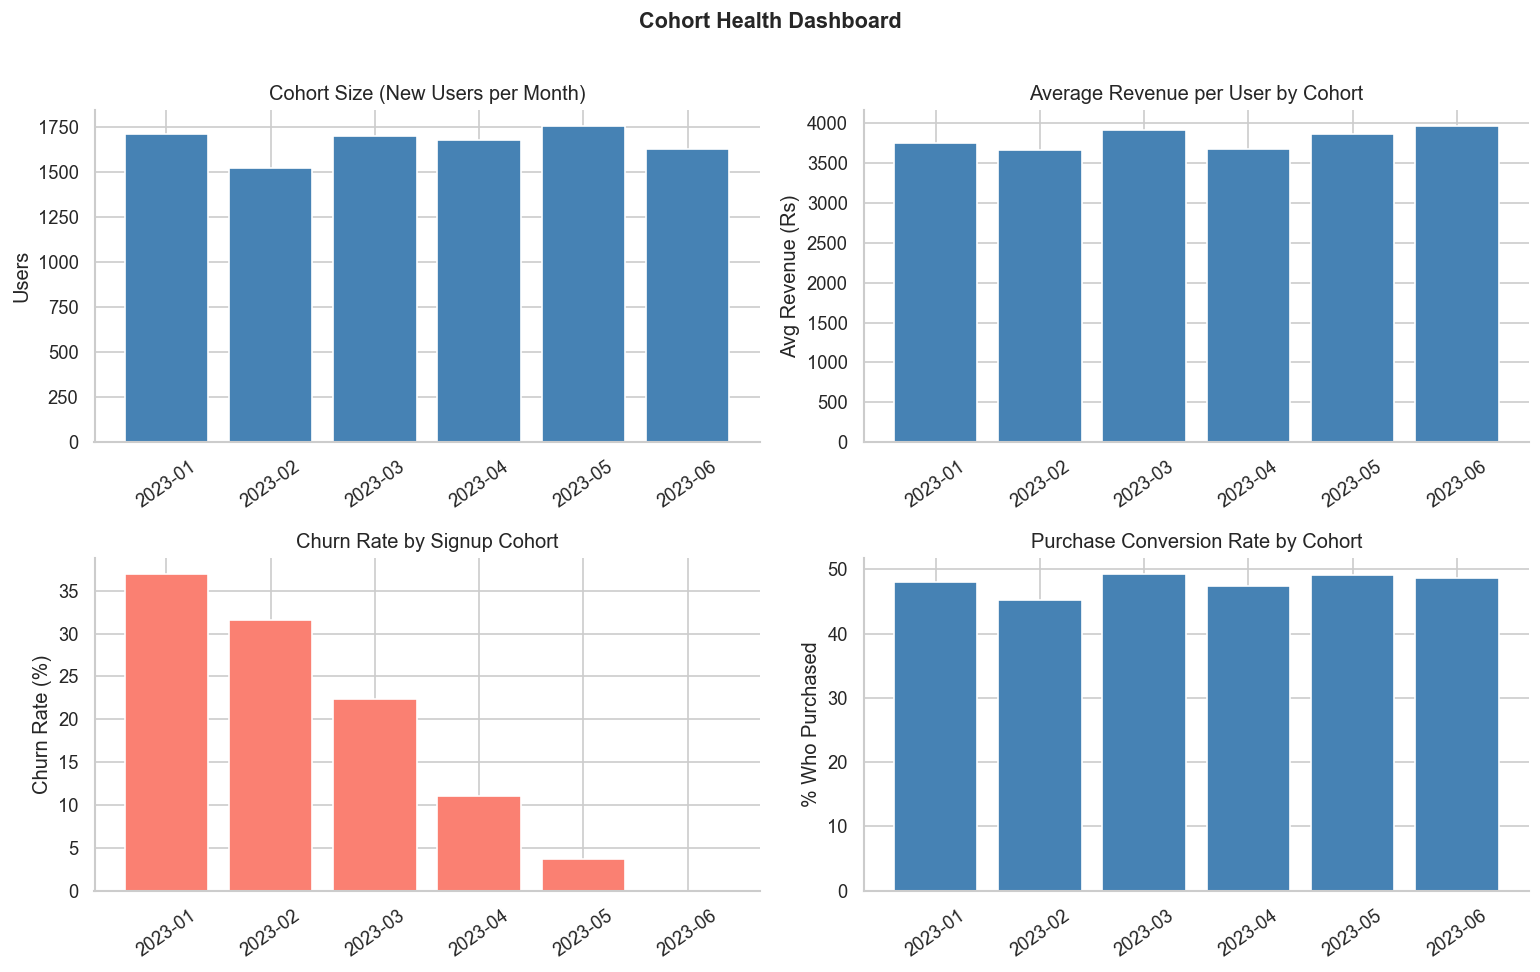

In [28]:
cohort_summary = (
    user_data.groupby('cohort_month')
    .agg(
        cohort_size     = ('user_id', 'count'),
        avg_revenue     = ('total_revenue', 'mean'),
        churn_rate      = ('churn', 'mean'),
        purchase_rate   = ('has_purchased', 'mean')
    )
    .reset_index()
)
cohort_summary['cohort_month'] = cohort_summary['cohort_month'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].bar(cohort_summary['cohort_month'], cohort_summary['cohort_size'],
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Cohort Size (New Users per Month)')
axes[0,0].set_ylabel('Users')
axes[0,0].tick_params(axis='x', rotation=35)

axes[0,1].bar(cohort_summary['cohort_month'], cohort_summary['avg_revenue'],
              color='steelblue', edgecolor='white')
axes[0,1].set_title('Average Revenue per User by Cohort')
axes[0,1].set_ylabel('Avg Revenue (Rs)')
axes[0,1].tick_params(axis='x', rotation=35)

axes[1,0].bar(cohort_summary['cohort_month'], cohort_summary['churn_rate'] * 100,
              color='salmon', edgecolor='white')
axes[1,0].set_title('Churn Rate by Signup Cohort')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=35)

axes[1,1].bar(cohort_summary['cohort_month'], cohort_summary['purchase_rate'] * 100,
              color='steelblue', edgecolor='white')
axes[1,1].set_title('Purchase Conversion Rate by Cohort')
axes[1,1].set_ylabel('% Who Purchased')
axes[1,1].tick_params(axis='x', rotation=35)

plt.suptitle('Cohort Health Dashboard', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation:** The four-panel cohort dashboard gives a complete picture of acquisition health over time. The ideal trend is: stable or growing cohort size, stable or rising average revenue, declining churn rate, and stable or rising purchase conversion. If cohort size is growing but churn and revenue are deteriorating, growth is masking a quality problem — the business is acquiring more users but getting less value from each one. This pattern is unsustainable and represents a significant risk if acquisition spend is not adjusted.

---
## Step 5: Summary

In [29]:
best_retention_cohort = retention_matrix.iloc[:, 1].idxmax() if retention_matrix.shape[1] > 1 else 'N/A'
best_ltv_cohort       = ltv_by_cohort.index[0]
avg_repeat_rate       = repeat_by_cohort['repeat_rate_pct'].mean()

print('='*60)
print('  COHORT ANALYSIS — SUMMARY')
print('='*60)
print(f'  Cohorts analysed            : {len(cohort_summary)}')
print(f'  Best month-1 retention      : {best_retention_cohort}')
print(f'  Highest LTV cohort          : {best_ltv_cohort}')
print(f'  Avg repeat purchase rate    : {avg_repeat_rate:.1f}%')
print(f'  Cohort with highest revenue : {cohort_summary.loc[cohort_summary["avg_revenue"].idxmax(), "cohort_month"]}')
print(f'  Cohort with lowest churn    : {cohort_summary.loc[cohort_summary["churn_rate"].idxmin(), "cohort_month"]}')
print('='*60)
print('\nReady for Phase 8: Marketing Analysis')

  COHORT ANALYSIS — SUMMARY
  Cohorts analysed            : 6
  Best month-1 retention      : 2023-05
  Highest LTV cohort          : 2023-06
  Avg repeat purchase rate    : 90.7%
  Cohort with highest revenue : 2023-06
  Cohort with lowest churn    : 2023-06

Ready for Phase 8: Marketing Analysis


---
## Key Findings

**1. Cohort retention heatmap reveals product stickiness with right-censoring control.**  
Reading across each cohort row shows how quickly users disengage after signing up. Recent cohorts have fewer observable months, so comparisons should be made at the same lifecycle month.

**2. LTV curves separate high-value from low-value cohorts.**  
Not all acquired users are equal in long-term revenue contribution. The cohort with the steepest LTV curve is the acquisition target profile; the marketing team should reverse-engineer what drove that cohort.

**3. Repeat purchase rate measures product habit formation.**  
A platform where most buyers only purchase once is not building a recurring revenue base. Low repeat rates across cohorts signal a product or post-purchase experience problem.

**4. Cohort health dashboard catches quality-vs-quantity traps.**  
Growing cohort sizes with declining revenue and rising churn means the business is growing in volume but shrinking in quality. This pattern requires acquisition and onboarding review.

**5. Cohort analysis controls for time better than snapshot metrics.**  
An overall churn rate can hide whether churn is broad-based or concentrated in a specific cohort. Cohort analysis identifies which lifecycle window or acquisition period needs action.
